In [4]:
import warnings
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

warnings.filterwarnings("ignore")

In [ ]:
import pickle

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Final Eco/target_enoded.csv")
data.head(15)

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Wilderness_Area_4,Hydro_fire_interaction,Wilderness_Area_3,Soil_Type_10,Horizontal_Distance_To_Hydrology,Euclidean_Distance_To_Hydrology,Soil_Type_3,...,Hillshade_9am,Aspect,Hillshade_3pm,Hillshade_Noon,Vertical_Distance_To_Hydrology,Slop_elevation_interaction,Soil_Type_38,Slope,Soil_Type_29,Cover_Type
0,0.228113,0.071659,0.930941,0,0.908889,0,0,0.579234,0.573050,0,...,0.453011,0.410781,0.552632,0.581044,0.550705,0.247178,0,0.243185,1,0
1,0.222276,0.054798,0.926627,0,0.908230,0,0,0.523712,0.517783,0,...,0.440134,0.429818,0.572368,0.632096,0.506866,0.195971,0,0.179015,1,0
2,0.430447,0.446817,0.918268,0,0.894955,0,0,0.590603,0.593061,0,...,0.638885,0.656911,0.467105,0.684992,0.818508,0.481929,0,0.515921,0,4
3,0.411965,0.434172,0.925505,0,0.904596,0,0,0.560555,0.585293,0,...,0.703415,0.690014,0.381579,0.684992,1.000000,0.711125,0,0.789906,0,4
4,0.227140,0.054939,0.922375,0,0.908725,0,0,0.442310,0.436601,0,...,0.440134,0.386397,0.565789,0.614876,0.544189,0.196187,0,0.179015,1,0
5,0.211576,0.009414,0.910982,0,0.884721,0,0,0.625570,0.619701,0,...,0.577913,0.641701,0.500000,0.667152,0.430891,0.365133,0,0.395691,1,4
6,0.237840,0.088942,0.929105,0,0.906001,0,0,0.592850,0.586690,0,...,0.466083,0.386397,0.486842,0.468858,0.577530,0.400884,0,0.438371,1,0
7,0.236868,0.080511,0.926867,0,0.906662,0,0,0.550975,0.544985,0,...,0.466083,0.402854,0.526316,0.548012,0.587211,0.291677,0,0.299259,1,0
8,0.248541,0.093579,0.928146,0,0.907488,0,0,0.558176,0.559656,0,...,0.479351,0.386397,0.453947,0.408955,0.785501,0.463427,0,0.515921,1,0
9,0.243677,0.089363,0.927027,0,0.905753,0,0,0.566460,0.560592,0,...,0.548717,0.440754,0.394737,0.380111,0.605720,0.491431,0,0.551592,1,0


In [ ]:
data.Cover_Type.value_counts()

,count
Cover_Type,
0,103071
4,103071
6,103071
3,103071
5,103071
2,103071
1,103071


In [ ]:
data.shape

(721497, 21)

**Splitting Data**

In [ ]:
X= data.drop(columns=["Cover_Type"])
y= data["Cover_Type"]

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=0)

In [5]:
df_resampled = pd.read_csv("/content/drive/MyDrive/final col transfer/oversampled_data.csv")

In [12]:
df_resampled.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Hydro_fire_interaction,Slop_elevation_interaction
count,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000,721497.000000
mean,2753.965147,151.000934,15.261633,211.250772,40.217111,2078.953242,216.167938,220.710002,135.725657,1914.242990,2.515839,19.103334,217.241098,190.867866,1707.775070,41212.780767
std,345.310474,100.799379,7.360873,179.218284,39.209554,1583.178204,22.973435,17.488401,37.386271,1530.876776,1.300256,12.357561,181.178522,13.178715,1504.429499,18923.454446
min,2361.500000,0.000000,0.000000,0.000000,-59.000000,0.000000,169.500000,186.000000,64.000000,0.000000,1.000000,1.000000,0.000000,139.833333,0.000000,0.000000
25%,2378.045749,70.000000,9.000000,68.493503,6.209742,849.747109,201.389729,209.427903,111.303762,784.666261,1.000000,10.000000,72.250199,183.128913,601.496444,26130.000000
50%,2726.000000,124.000000,14.000000,170.000000,29.910853,1457.038408,220.103061,223.000000,138.000000,1421.826751,3.000000,17.000000,177.507811,193.258525,1228.177053,40172.134772
75%,3001.000000,227.116644,21.000000,306.000000,68.542647,3182.315621,233.000000,233.850917,161.103287,2513.897547,4.000000,29.000000,316.388827,200.670256,2318.181739,56676.000000
max,3389.500000,360.000000,27.000000,762.500000,117.000000,7117.000000,254.000000,254.000000,216.000000,7173.000000,4.000000,40.000000,771.424170,213.666667,7173.000000,91516.500000


In [ ]:
df_resampled.shape


(721497, 18)

In [ ]:
df_resampled.select_dtypes(exclude = ["object"]).columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction'],
      dtype='object')

In [ ]:
data_col = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction']

In [ ]:
skew = df_resampled[data_col].skew()
skew

,0
Elevation,0.411441
Aspect,0.553280
Slope,0.156773
Horizontal_Distance_To_Hydrology,1.088828
Vertical_Distance_To_Hydrology,0.590135
Horizontal_Distance_To_Roadways,0.872230
Hillshade_9am,-0.510505
Hillshade_Noon,-0.397355
Hillshade_3pm,-0.119884
Horizontal_Distance_To_Fire_Points,1.303227


In [ ]:
data_skew = skew[abs((skew)>0.5)]
data_skew

,0
Aspect,0.553280
Horizontal_Distance_To_Hydrology,1.088828
Vertical_Distance_To_Hydrology,0.590135
Horizontal_Distance_To_Roadways,0.872230
Horizontal_Distance_To_Fire_Points,1.303227
Euclidean_Distance_To_Hydrology,1.037400
Hydro_fire_interaction,1.354982


In [ ]:
data_skew = skew[abs((skew)<0.5)]
data_skew

,0
Elevation,0.411441
Slope,0.156773
Hillshade_9am,-0.510505
Hillshade_Noon,-0.397355
Hillshade_3pm,-0.119884
Hillshade_Avg,-0.700184
Slop_elevation_interaction,0.130383


In [ ]:
nominal_data = ['Wilderness_Area', 'Soil_Type','Aspect_Category']  # OHE
pos_skewed_cols = ['Aspect', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology','Horizontal_Distance_To_Roadways','Horizontal_Distance_To_Fire_Points','Euclidean_Distance_To_Hydrology','Hydro_fire_interaction']  #yoe jhonson transform
scaling_cols = ['Elevation','Slope','Hillshade_9am','Hillshade_Noon','Hillshade_3pm','Hillshade_Avg','Slop_elevation_interaction']  # Standard Scaler


**Label encoding the output variables**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
df_resampled["Cover_Type"]=le.fit_transform(df_resampled["Cover_Type"])
df_resampled.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Aspect_Category,Hydro_fire_interaction,Slop_elevation_interaction,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,1,29,258.000000,200.333333,East,6021.0,7788.0,0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,1,29,212.084889,202.000000,East,6013.0,5180.0,0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,1,12,275.769832,202.333333,South,5853.0,25236.0,4
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,1,30,268.799182,199.333333,South,5969.0,50130.0,4
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,1,29,153.003268,201.333333,East,6019.0,5190.0,0


In [ ]:
import pickle

# Define the path to save the label encoder
label_encoder_save_path = '/content/label_encoder.pkl'

# Save the label encoder using pickle
with open(label_encoder_save_path, 'wb') as f:
    pickle.dump(le, f)

print(f"LabelEncoder saved to: {label_encoder_save_path}")

LabelEncoder saved to: /content/label_encoder.pkl


In [ ]:
import pickle

# Define the path to save the YeoJohnsonTransformer
yj_transformer_save_path = '/content/yj_transformer.pkl'

# Save the transformer using pickle
with open(yj_transformer_save_path, 'wb') as f:
    pickle.dump(yj_transformer, f)

print(f"YeoJohnsonTransformer saved to: {yj_transformer_save_path}")

YeoJohnsonTransformer saved to: /content/yj_transformer.pkl


In [ ]:
import pickle

# Define the path to save the MinMaxScaler
scaler_save_path = '/content/min_max_scaler.pkl'

# Save the scaler using pickle
with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"MinMaxScaler saved to: {scaler_save_path}")

MinMaxScaler saved to: /content/min_max_scaler.pkl


In [6]:
import pickle

# Define the path to save the OneHotEncoder
ohe_save_path = '/content/one_hot_encoder.pkl'

# Save the encoder using pickle
with open(ohe_save_path, 'wb') as f:
    pickle.dump(ohe, f)

print(f"OneHotEncoder saved to: {ohe_save_path}")

OneHotEncoder saved to: /content/one_hot_encoder.pkl


**Scaling the numerical columns**

In [ ]:
pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 4.2 MB/s eta 0:00:00


In [ ]:
from feature_engine.transformation import YeoJohnsonTransformer
import matplotlib.pyplot as plt

Skewness after Yeo-Johnson Transformation:
Aspect                               -0.095681
Horizontal_Distance_To_Hydrology     -0.168412
Vertical_Distance_To_Hydrology       -0.137393
Horizontal_Distance_To_Roadways      -0.049406
Hillshade_9am                        -0.105424
Horizontal_Distance_To_Fire_Points   -0.013945
Euclidean_Distance_To_Hydrology      -0.181739
Hillshade_Avg                        -0.100380
Hydro_fire_interaction               -0.019787
dtype: float64


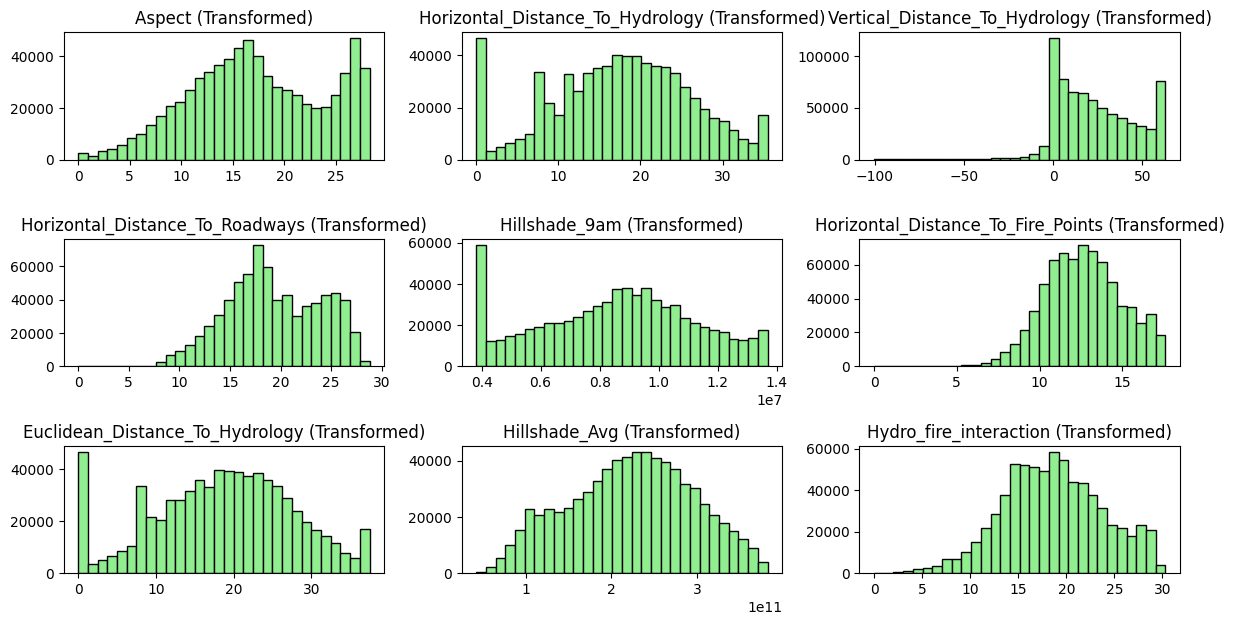

In [ ]:
datas_skewness = skew[abs(skew)>0.5]
yj_transformer = YeoJohnsonTransformer(variables=datas_skewness.index.tolist())
data_transformed = yj_transformer.fit_transform(df_resampled[datas_skewness.index.tolist()])

# Replace original skewed columns with transformed ones in the main DataFrame
for col in datas_skewness.index:
    df_resampled[col] = data_transformed[col]

# Recheck skewness after transformation
skewness_after_yj = df_resampled[datas_skewness.index].skew()
print("Skewness after Yeo-Johnson Transformation:")
print(skewness_after_yj)

# Visualize the distributions after transformation for the highly skewed features
plt.figure(figsize=(12, 8))
for i, col in enumerate(datas_skewness.index):
    plt.subplot(4, 3, i + 1)
    plt.hist(df_resampled[col], bins=30, color='lightgreen', edgecolor='black')
    plt.title(f'{col} (Transformed)')
plt.tight_layout()
plt.show()

In [ ]:
df_resampled.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Aspect_Category,Hydro_fire_interaction,Slop_elevation_interaction,Cover_Type
0,2596.0,10.702568,3.0,21.773507,0.000000,13.805130,8.815260e+06,232.0,148.0,17.146385,1,29,22.667291,2.728861e+11,East,28.910818,7788.0,Aspen
1,2590.0,11.239179,2.0,19.888509,-7.429802,12.727433,8.689850e+06,235.0,151.0,17.117052,1,29,20.673193,2.850203e+11,East,28.900396,5180.0,Aspen
2,2804.0,17.818051,9.0,22.156733,38.339165,23.223725,1.056026e+07,238.0,135.0,17.059938,1,12,23.384032,2.874989e+11,South,28.689706,25236.0,Lodgepole Pine
3,2785.0,18.801225,18.0,21.141901,63.009812,23.043499,1.114137e+07,238.0,122.0,17.109412,1,30,23.106116,2.658088e+11,South,28.842887,50130.0,Lodgepole Pine
4,2595.0,10.019068,2.0,17.080227,-1.066581,12.737410,8.689850e+06,234.0,150.0,17.088049,1,29,17.700996,2.801152e+11,East,28.908213,5190.0,Aspen


In [ ]:
df_resampled.select_dtypes(exclude = ["object"]).columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction', 'Cover_Type'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction']

df_resampled[numerical_cols] = scaler.fit_transform(df_resampled[numerical_cols])
df_resampled.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Aspect_Category,Hydro_fire_interaction,Slop_elevation_interaction,Cover_Type
0,0.228113,0.378841,0.111111,0.613909,0.614662,0.479440,0.506622,0.676471,0.552632,0.974063,1,29,0.604727,0.678101,East,0.953770,0.085099,0
1,0.222276,0.397835,0.074074,0.560761,0.569225,0.442013,0.493917,0.720588,0.572368,0.972396,1,29,0.551527,0.713645,East,0.953426,0.056602,0
2,0.430447,0.630708,0.333333,0.624714,0.849126,0.806540,0.683404,0.764706,0.467105,0.969152,1,12,0.623848,0.720905,South,0.946476,0.275754,4
3,0.411965,0.665510,0.666667,0.596101,1.000000,0.800281,0.742275,0.764706,0.381579,0.971962,1,30,0.616434,0.657371,South,0.951529,0.547770,4
4,0.227140,0.354647,0.074074,0.481581,0.608140,0.442359,0.493917,0.705882,0.565789,0.970749,1,29,0.472234,0.699277,East,0.953684,0.056711,0


In [17]:
from sklearn.preprocessing import OneHotEncoder
import pickle

# Corrected categorical columns for OneHotEncoder
cat_col = ['Soil_Type', 'Wilderness_Area']

# Initialize OneHotEncoder
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Fit and transform the data
encoded_data = ohe.fit_transform(df_resampled[cat_col])
encoded_data = encoded_data.astype(int)

encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(cat_col))

datas_encoded = pd.concat([df_resampled.drop(columns=cat_col), encoded_df], axis=1)

# Save the fitted OneHotEncoder
ohe_save_path = '/content/one_hot_encoder.pkl'
with open(ohe_save_path, 'wb') as f:
    pickle.dump(ohe, f)

print(f"OneHotEncoder fitted and saved to: {ohe_save_path}")

display(datas_encoded.head())

OneHotEncoder fitted and saved to: /content/one_hot_encoder.pkl


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0,0,0,0,0,0,0,0,0,0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0,0,0,0,0,0,0,0,0,0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0,0,0,0,0,0,0,0,0,0
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,...,0,0,0,0,0,0,0,0,0,0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data_feature = /content/best_random_forest_model.pkl

In [ ]:
data_model=datas_encoded[data_feature]

In [ ]:
data_model.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Wilderness_Area_4,Hydro_fire_interaction,Wilderness_Area_3,Soil_Type_10,Horizontal_Distance_To_Hydrology,Euclidean_Distance_To_Hydrology,Soil_Type_3,...,Hillshade_9am,Aspect,Hillshade_3pm,Hillshade_Noon,Vertical_Distance_To_Hydrology,Slop_elevation_interaction,Soil_Type_38,Slope,Soil_Type_29,Cover_Type
0,0.228113,0.479440,0.974063,0,0.953770,0,0,0.613909,0.604727,0,...,0.506622,0.378841,0.552632,0.676471,0.614662,0.085099,0,0.111111,1,0
1,0.222276,0.442013,0.972396,0,0.953426,0,0,0.560761,0.551527,0,...,0.493917,0.397835,0.572368,0.720588,0.569225,0.056602,0,0.074074,1,0
2,0.430447,0.806540,0.969152,0,0.946476,0,0,0.624714,0.623848,0,...,0.683404,0.630708,0.467105,0.764706,0.849126,0.275754,0,0.333333,0,4
3,0.411965,0.800281,0.971962,0,0.951529,0,0,0.596101,0.616434,0,...,0.742275,0.665510,0.381579,0.764706,1.000000,0.547770,0,0.666667,0,4
4,0.227140,0.442359,0.970749,0,0.953684,0,0,0.481581,0.472234,0,...,0.493917,0.354647,0.565789,0.705882,0.608140,0.056711,0,0.074074,1,0


In [ ]:
data_model.to_csv()

In [ ]:
data_model.shape

(721497, 21)

In [ ]:
data_model["Cover_Type"]=df_resampled['Cover_Type']

In [ ]:
data_model.to_csv("/content/drive/MyDrive/data_model.csv")

In [ ]:
data_model.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Wilderness_Area_4,Hydro_fire_interaction,Wilderness_Area_3,Soil_Type_10,Horizontal_Distance_To_Hydrology,Euclidean_Distance_To_Hydrology,Soil_Type_3,...,Hillshade_9am,Aspect,Hillshade_3pm,Hillshade_Noon,Vertical_Distance_To_Hydrology,Slop_elevation_interaction,Soil_Type_38,Slope,Soil_Type_29,Cover_Type
0,0.228113,0.479440,0.974063,0,0.953770,0,0,0.613909,0.604727,0,...,0.506622,0.378841,0.552632,0.676471,0.614662,0.085099,0,0.111111,1,0
1,0.222276,0.442013,0.972396,0,0.953426,0,0,0.560761,0.551527,0,...,0.493917,0.397835,0.572368,0.720588,0.569225,0.056602,0,0.074074,1,0
2,0.430447,0.806540,0.969152,0,0.946476,0,0,0.624714,0.623848,0,...,0.683404,0.630708,0.467105,0.764706,0.849126,0.275754,0,0.333333,0,4
3,0.411965,0.800281,0.971962,0,0.951529,0,0,0.596101,0.616434,0,...,0.742275,0.665510,0.381579,0.764706,1.000000,0.547770,0,0.666667,0,4
4,0.227140,0.442359,0.970749,0,0.953684,0,0,0.481581,0.472234,0,...,0.493917,0.354647,0.565789,0.705882,0.608140,0.056711,0,0.074074,1,0


**Splitting Data**

In [ ]:
X= data_model.drop(columns=["Cover_Type"])
y= data_model["Cover_Type"]

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
y_train

,Cover_Type
324866,1
685050,6
554234,5
98077,6
655046,6
...,...
359783,2
152315,0
117952,4
435829,2


In [ ]:
X_train.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Wilderness_Area_4,Hydro_fire_interaction,Wilderness_Area_3,Soil_Type_10,Horizontal_Distance_To_Hydrology,Euclidean_Distance_To_Hydrology,Soil_Type_3,Hillshade_Avg,Hillshade_9am,Aspect,Hillshade_3pm,Hillshade_Noon,Vertical_Distance_To_Hydrology,Slop_elevation_interaction,Soil_Type_38,Slope,Soil_Type_29
324866,0.000000,0.397514,0.752687,1,0.662682,0,0,0.509354,0.531844,1,0.226964,0.987943,0.592416,0.000000,0.142659,0.934787,0.696710,0,1.000000,0
685050,0.791704,0.961276,0.661942,0,0.515301,0,0,0.672336,0.664296,0,0.832579,0.423446,0.780313,0.664407,0.828071,0.712624,0.138789,0,0.148148,1
554234,0.000107,0.421160,0.625756,1,0.465008,0,1,0.650848,0.663930,0,0.497498,0.000000,0.941295,0.815420,0.425645,0.995092,0.567717,0,0.814815,0
98077,0.609436,0.875083,0.889391,0,0.840503,0,0,0.547077,0.538521,0,0.347956,0.585501,0.386556,0.296053,0.308824,0.685287,0.489748,0,0.555556,1
655046,0.655307,0.945784,0.826543,0,0.743671,0,0,0.710692,0.702615,0,0.615972,0.759896,0.625729,0.366192,0.690873,0.431645,0.464312,0,0.518519,1


In [ ]:
y_train.value_counts()

,count
Cover_Type,
6,82678
2,82532
1,82502
0,82479
5,82423
3,82305
4,82278


In [ ]:

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost Classifier": XGBClassifier(n_estimators= 200, use_label_encoder=False, eval_metric='mlogloss', objective='multi:softmax')
}

# Loop through models
for name, model in models.items():
    pipeline = Pipeline([
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    # Make predictions on training data
    y_train_pred = pipeline.predict(X_train)
    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Make predictions on test data
    y_test_pred = pipeline.predict(X_test)
    # Calculate test accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"{name}:\n  Training Accuracy = {train_accuracy:.4f}\n  Testing Accuracy = {test_accuracy:.4f}")



Logistic Regression:
  Training Accuracy = 0.7458
  Testing Accuracy = 0.7464
Decision Tree:
  Training Accuracy = 1.0000
  Testing Accuracy = 0.9733
K-Nearest Neighbors:
  Training Accuracy = 0.9731
  Testing Accuracy = 0.9586
Random Forest:
  Training Accuracy = 1.0000
  Testing Accuracy = 0.9893
XGBoost Classifier:
  Training Accuracy = 0.9888
  Testing Accuracy = 0.9816


In [ ]:
if name == "XGBoost Classifier":
     xgb_pipeline = pipeline

In [ ]:
with open("/content/drive/MyDrive/eco_final_19.04.26/xgp_model.pkl", "wb") as f:
  pickle.dump(xgb_pipeline,f)

In [ ]:
random_forest_model_instance = models["Random Forest"]
random_forest_pipeline = Pipeline([('classifier', random_forest_model_instance)])
random_forest_pipeline.fit(X_train, y_train)

with open("/content/drive/MyDrive/Final Eco/pickle_file/random_forest_model.pkl", "wb") as f:
  pickle.dump(random_forest_pipeline,f)

In [ ]:
with open ('/content/drive/MyDrive/eco_final_19.04.26/models.pkl', 'wb') as file:
  pickle.dump(pipeline, file)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Define number of folds for Stratified Cross-Validation
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Dictionary to store results
model_results = {}

# Loop through models and apply StratifiedCV
for name, model in models.items():
    pipeline = Pipeline([
        ('classifier', model)
    ])

    # Perform Stratified Cross-Validation
    scores = cross_val_score(pipeline, X, y, cv=stratified_kfold, scoring='accuracy')

    # Store mean accuracy
    model_results[name] = scores.mean()
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}")

Logistic Regression: Mean Accuracy = 0.7435
Decision Tree: Mean Accuracy = 0.9734
K-Nearest Neighbors: Mean Accuracy = 0.9580
Random Forest: Mean Accuracy = 0.9892
XGBoost Classifier: Mean Accuracy = 0.9818


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
X= data_model.drop(columns=["Cover_Type"])
y= data_model["Cover_Type"]

In [ ]:
# Hyperparameter grid for XGBoost
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],  # More trees to learn better
    'classifier__max_depth': [5,7,8],  # Avoid excessive depth
    'classifier__learning_rate': [0.03, 0.05, 0.1],  # Balance between learning & generalization
    'classifier__min_child_weight': [1, 2],  # Allow smaller splits
    'classifier__gamma': [0, 0.05]  # Less aggressive regularization
    }

# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('classifier', XGBClassifier(enable_categorical=True, eval_metric='logloss'))
])


# Perform GridSearchCV for XGBoost
xgb_search = RandomizedSearchCV(xgb_pipeline,xgb_param_grid,cv=5, verbose=1, n_jobs=-1)
xgb_search.fit(X, y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [ ]:
# Hyperparameter grid for Random Forest
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__max_depth' : [4,5,6,7,8],
    'classifier__criterion' :['gini', 'entropy'],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=0))
])

# Perform RandomizedSearchCV for Random Forest
rf_search = RandomizedSearchCV(rf_pipeline, rf_param_grid, cv=5, verbose=1, n_jobs=-1)
rf_search.fit(X, y)

print(f"Best parameters for Random Forest: {rf_search.best_params_}")
print(f"Best cross-validation accuracy for Random Forest: {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Regarding computational cost: It's difficult to say definitively whether Random Forest will be 'less' computational than XGBoost without specific hyperparameter settings for both. Both are powerful ensemble models that can be computationally intensive during hyperparameter tuning.

*   **Random Forest:** Builds multiple independent decision trees and averages their predictions. This process is highly parallelizable.
*   **XGBoost:** Builds trees sequentially, with each new tree correcting errors from previous ones. While sequential in nature, XGBoost is highly optimized for performance and uses techniques like regularization and gradient boosting, often making it very fast in practice.

The number of estimators, depth of trees, and especially the number of cross-validation folds (`cv`) and the number of random search iterations (`n_iter`, which defaults to 10 if not specified) will significantly impact the total runtime for both algorithms. You can try adjusting the `cv` value or reducing the number of `n_estimators` or `max_depth` in the search space to get a quicker result if needed.

In [ ]:
import pickle

# Get the best model from RandomizedSearchCV
best_xgb_model = xgb_search.best_estimator_

# Define the path to save the model
model_save_path = '/content/drive/MyDrive/eco_final_19.04.26/best_xgb_random_search_model.pkl'

# Save the best model using pickle
with open(model_save_path, 'wb') as f:
    pickle.dump(best_xgb_model, f)

print(f"Best XGBoost model saved to: {model_save_path}")

from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Take only 30% of the training data for hyperparameter search
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=0.3, stratify=y_train, random_state=42
)

# Run Random Search on the subset
random_search = RandomizedSearchCV(estimator=model, ..., n_jobs=-1)
random_search.fit(X_train_sub, y_train_sub)


In [ ]:
# Take only 30% of the training data for hyperparameter search
# Adjust 'train_size' as needed (e.g., 0.1 for 10% or 0.5 for 50%)
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=0.3, stratify=y_train, random_state=42
)

print(f"Subset size for hyperparameter search: {X_train_sub.shape[0]} samples")

Subset size for hyperparameter search: 173159 samples


In [ ]:
# Hyperparameter grid for XGBoost (from cell 'ko-z9MAYy4Se')
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5,7,8],
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__min_child_weight': [1, 2],
    'classifier__gamma': [0, 0.05]
}

# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('classifier', XGBClassifier(enable_categorical=True, eval_metric='logloss', use_label_encoder=False))
])

# Perform RandomizedSearchCV for XGBoost on the subset
xgb_search_subset = RandomizedSearchCV(xgb_pipeline, xgb_param_grid, cv=3, verbose=1, n_jobs=-1, n_iter=5, random_state=42)
xgb_search_subset.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters for XGBoost (on subset): {xgb_search_subset.best_params_}")
print(f"Best cross-validation accuracy for XGBoost (on subset): {xgb_search_subset.best_score_:.4f}")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Hyperparameter grid for Random Forest (from cell '8d71feba')
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__max_depth' : [4,5,6,7,8],
    'classifier__criterion' :['gini', 'entropy'],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=0))
])

# Perform RandomizedSearchCV for Random Forest on the subset
rf_search_subset = RandomizedSearchCV(rf_pipeline, rf_param_grid, cv=3, verbose=1, n_jobs=-1, n_iter=5, random_state=42)
rf_search_subset.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters for Random Forest (on subset): {rf_search_subset.best_params_}")
print(f"Best cross-validation accuracy for Random Forest (on subset): {rf_search_subset.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best parameters for Random Forest (on subset): {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 7, 'classifier__criterion': 'gini'}
Best cross-validation accuracy for Random Forest (on subset): 0.8127


In [ ]:
import pickle

best_model = rf_search_subset.best_estimator_

file_name = 'best_random_forest_model.pkl'
with open(file_name, 'wb') as f:
  pickle.dump(best_model,f)
print(f"Model saved to {file_name}")

Model saved to best_random_forest_model.pkl


In [12]:
!pip install streamlit streamlit_option_menu  # installing streamlit and streamlit_option_menu packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 4.1 MB/s eta 0:00:00


In [16]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 1.3 MB/s eta 0:00:00


In [20]:
%%writefile "/content/eco.py"
import streamlit as st
import pickle
import pandas as pd
import numpy as np
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder

# 1. Sets the browser tab title
st.set_page_config(page_title="Eco Forest Type Prediction App")

st.title("Eco Forest Type Prediction")

# -------------------------------
# Load model and transformers
# -------------------------------
try:
    with open("/content/drive/MyDrive/Final Eco/pickle file_1/best_random_forest_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("/content/drive/MyDrive/Final Eco/pickle file_1/label_encoder (1).pkl", "rb") as f:
        label_encoder = pickle.load(f)
    with open("/content/drive/MyDrive/Final Eco/pickle file_1/yj_transformer.pkl", "rb") as f:
        yj_transformer = pickle.load(f)
    with open("/content/drive/MyDrive/Final Eco/pickle file_1/min_max_scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    with open("/content/drive/MyDrive/Final Eco/pickle file_1/one_hot_encoder (1).pkl", "rb") as f:
        ohe = pickle.load(f)
except FileNotFoundError as e:
    st.error(f"Error loading a required file: {e}. Please ensure all model and transformer files are saved correctly.")
    st.stop()


# Define feature lists for preprocessing (from the notebook)
yj_cols = ['Aspect', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
           'Horizontal_Distance_To_Roadways', 'Horizontal_Distance_To_Fire_Points',
           'Euclidean_Distance_To_Hydrology', 'Hydro_fire_interaction', 'Hillshade_9am', 'Hillshade_Avg']

minmax_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
               'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
               'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
               'Horizontal_Distance_To_Fire_Points', 'Euclidean_Distance_To_Hydrology',
               'Hillshade_Avg', 'Hydro_fire_interaction', 'Slop_elevation_interaction']

ohe_cat_cols = ['Soil_Type', 'Wilderness_Area'] # Aspect_Category was not in final_model_cols

# Define the final columns the model expects (from X.columns in the notebook)
final_model_cols = ['Elevation', 'Horizontal_Distance_To_Roadways',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_4',
       'Hydro_fire_interaction', 'Wilderness_Area_3', 'Soil_Type_10',
       'Horizontal_Distance_To_Hydrology', 'Euclidean_Distance_To_Hydrology',
       'Soil_Type_3', 'Hillshade_Avg', 'Hillshade_9am', 'Aspect',
       'Hillshade_3pm', 'Hillshade_Noon', 'Vertical_Distance_To_Hydrology',
       'Slop_elevation_interaction', 'Soil_Type_38', 'Slope', 'Soil_Type_29']


# -------------------------------
# Define input fields (raw features)
# -------------------------------
st.header("Enter Feature Values:")

# Numerical Inputs
Elevation = st.number_input("Elevation (meters)", min_value=0.0, max_value=float(7000), value=2596.0)
Aspect = st.number_input("Aspect (degrees)", min_value=0.0, max_value=360.0, value=51.0)
Slope = st.number_input("Slope (degrees)", min_value=0.0, max_value=float(100), value=3.0)
Horizontal_Distance_To_Hydrology = st.number_input("Horizontal Distance To Hydrology (meters)", min_value=0.0, max_value=float(5000), value=258.0)
Vertical_Distance_To_Hydrology = st.number_input("Vertical Distance To Hydrology (meters)", min_value=float(-1000), max_value=float(1000), value=0.0)
Horizontal_Distance_To_Roadways = st.number_input("Horizontal Distance To Roadways (meters)", min_value=0.0, max_value=float(100000), value=510.0)
Hillshade_9am = st.number_input("Hillshade 9am (0-255)", min_value=0.0, max_value=255.0, value=221.0)
Hillshade_Noon = st.number_input("Hillshade Noon (0-255)", min_value=0.0, max_value=255.0, value=232.0)
Hillshade_3pm = st.number_input("Hillshade 3pm (0-255)", min_value=0.0, max_value=255.0, value=148.0)
Horizontal_Distance_To_Fire_Points = st.number_input("Horizontal Distance To Fire Points (meters)", min_value=0.0, max_value=float(10000), value=6279.0)
Euclidean_Distance_To_Hydrology = st.number_input("Euclidean Distance To Hydrology (meters)", min_value=0.0, max_value=float(2000), value=258.0)
Hillshade_Avg = st.number_input("Hillshade Average (0-255)", min_value=0.0, max_value=255.0, value=200.0)
Hydro_fire_interaction = st.number_input("Hydro Fire Interaction (meters)", min_value=0.0, max_value=float(10000), value=6021.0)
Slop_elevation_interaction = st.number_input("Slope Elevation Interaction (meters)", min_value=0.0, max_value=float(300000), value=7788.0)

# Categorical Inputs (using common options or ranges)
# Wilderness_Area values from original dataset: 1, 2, 3, 4
Wilderness_Area = st.selectbox("Wilderness Area", [1, 2, 3, 4], index=0)

# Soil_Type values from original dataset: 1-40
Soil_Type = st.selectbox("Soil Type", list(range(1, 41)), index=28) # Default to 29, as seen in df_resampled.head()

# -------------------------------
# Prediction
# -------------------------------
if st.button("Predict Cover Type"):
    # Create a DataFrame from raw inputs
    raw_input_df = pd.DataFrame({
        'Elevation': [Elevation],
        'Aspect': [Aspect],
        'Slope': [Slope],
        'Horizontal_Distance_To_Hydrology': [Horizontal_Distance_To_Hydrology],
        'Vertical_Distance_To_Hydrology': [Vertical_Distance_To_Hydrology],
        'Horizontal_Distance_To_Roadways': [Horizontal_Distance_To_Roadways],
        'Hillshade_9am': [Hillshade_9am],
        'Hillshade_Noon': [Hillshade_Noon],
        'Hillshade_3pm': [Hillshade_3pm],
        'Horizontal_Distance_To_Fire_Points': [Horizontal_Distance_To_Fire_Points],
        'Euclidean_Distance_To_Hydrology': [Euclidean_Distance_To_Hydrology],
        'Hillshade_Avg': [Hillshade_Avg],
        'Hydro_fire_interaction': [Hydro_fire_interaction],
        'Slop_elevation_interaction': [Slop_elevation_interaction],
        'Wilderness_Area': [Wilderness_Area],
        'Soil_Type': [Soil_Type]
    })

    # Apply Yeo-Johnson Transformation
    input_yj_transformed = raw_input_df.copy()
    if not input_yj_transformed[yj_cols].empty:
        input_yj_transformed[yj_cols] = yj_transformer.transform(input_yj_transformed[yj_cols])

    # Apply Min-Max Scaling
    input_scaled = input_yj_transformed.copy()
    if not input_scaled[minmax_cols].empty:
        input_scaled[minmax_cols] = scaler.transform(input_scaled[minmax_cols])

    # Apply One-Hot Encoding
    input_ohe_part = ohe.transform(raw_input_df[ohe_cat_cols])
    ohe_feature_names = ohe.get_feature_names_out(ohe_cat_cols)
    input_ohe_df = pd.DataFrame(input_ohe_part, columns=ohe_feature_names, index=raw_input_df.index)

    # Combine numerical (scaled) and OHE features
    # Drop original categorical columns from input_scaled before concatenating OHE features
    numerical_features_for_concat = input_scaled.drop(columns=ohe_cat_cols)
    processed_input_df = pd.concat([numerical_features_for_concat, input_ohe_df], axis=1)

    # Select and reorder columns to match the model's expected input
    # Handle missing columns by adding them with 0, and extra columns by dropping them
    final_input_df = pd.DataFrame(columns=final_model_cols)
    for col in final_model_cols:
        if col in processed_input_df.columns:
            final_input_df[col] = processed_input_df[col]
        else:
            final_input_df[col] = 0.0 # Add missing columns with default value 0

    # Ensure the order is correct
    final_input_df = final_input_df[final_model_cols]

    prediction_numerical = model.predict(final_input_df)[0]
    predicted_cover_type = label_encoder.inverse_transform([int(prediction_numerical)])[0]
    st.success(f"Predicted Cover Type: {predicted_cover_type}")

Overwriting /content/eco.py


In [9]:
!streamlit run /content/eco.py &>/content/logs.txt &

In [14]:
!streamlit run /content/eco.py &>/content/logs.txt &  # here instead of app.py please rename with your file name

###### **Executing the following code will generate a URL. Click it or copy and paste it in browser to view your streamlit page**

In [15]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://rod-clubs-vip-freelance.trycloudflare.com


In [13]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
!pkill -f cloudflared
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 > nohup.out 2>&1 &

--2026-04-21 01:23:06--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-04-21 01:23:06--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-21T02%3A20%3A38Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-21

In [31]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your new tunnel URL is: {}"

Your new tunnel URL is: https://pull-complexity-finish-steam.trycloudflare.com


In [ ]:
!pip install streamlit streamlit_option_menu  # installing streamlit and streamlit_option_menu packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 14.2 MB/s eta 0:00:00


In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://discussion-supports-bool-certificates.trycloudflare.com


In [19]:
df_resampled.head(15).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Elevation,2596.0,2590.0,2804.0,2785.0,2595.0,2579.0,2606.0,2605.0,2617.0,2612.0,2612.0,2886.0,2742.0,2609.0,2503.0
Aspect,51.0,56.0,139.0,155.0,45.0,132.0,45.0,49.0,45.0,59.0,201.0,151.0,134.0,214.0,157.0
Slope,3.0,2.0,9.0,18.0,2.0,6.0,7.0,4.0,9.0,10.0,4.0,11.0,22.0,7.0,4.0
Horizontal_Distance_To_Hydrology,258.0,212.0,268.0,242.0,153.0,300.0,270.0,234.0,240.0,247.0,180.0,371.0,150.0,150.0,67.0
Vertical_Distance_To_Hydrology,0.0,-6.0,65.0,117.0,-1.0,-15.0,5.0,7.0,56.0,11.0,51.0,26.0,69.0,46.0,4.0
Horizontal_Distance_To_Roadways,510.0,390.0,3180.0,3090.0,391.0,67.0,633.0,573.0,666.0,636.0,735.0,5253.0,3215.0,771.0,674.0
Hillshade_9am,221.0,220.0,234.0,238.0,220.0,230.0,222.0,222.0,223.0,228.0,218.0,234.0,248.0,213.0,224.0
Hillshade_Noon,232.0,235.0,238.0,238.0,234.0,237.0,225.0,230.0,221.0,219.0,243.0,240.0,224.0,247.0,240.0
Hillshade_3pm,148.0,151.0,135.0,122.0,150.0,140.0,138.0,144.0,133.0,124.0,161.0,136.0,92.0,170.0,151.0
Horizontal_Distance_To_Fire_Points,6279.0,6225.0,6121.0,6211.0,6172.0,6031.0,6256.0,6228.0,6244.0,6230.0,6222.0,4051.0,6091.0,6211.0,5600.0
